# **Diplomado IA: Inteligencia Artificial II - Métodos de Profundización**. <br> Práctico: Meta Aprendizaje (Parte 1)
---
---

**Profesor:** Pablo Messina (pamessina@uc.cl)


# Introducción

Este laboratorio está basado fuertemente en [learn2learn](https://learn2learn.net/examples/vision/), una librería open-source para investigación en meta-learning.

En particular, veremos el uso de dos métodos concretos:

1) Model-Agnostic Meta-Learning (MAML): https://arxiv.org/abs/1703.03400

2) Prototypical Networks for Few-shot Learning: https://arxiv.org/abs/1703.05175

Los datasets que usaremos son Omniglot y Mini-ImageNet, y los códigos consultados para la confección de este laboratorio son los siguientes:

- https://github.com/learnables/learn2learn/blob/master/examples/vision/maml_omniglot.py
- https://github.com/learnables/learn2learn/blob/master/examples/vision/maml_miniimagenet.py
- https://github.com/learnables/learn2learn/blob/master/examples/vision/protonet_miniimagenet.py


# Instalando e importando librerías a usar

Instalamos learn2learn desde GitHub primero debido al siguiente issue: https://github.com/learnables/learn2learn/issues/433

In [ ]:
!git clone https://github.com/learnables/learn2learn.git
%cd learn2learn
!pip install -e .

fatal: destination path 'learn2learn' already exists and is not an empty directory.
/content/learn2learn
Obtaining file:///content/learn2learn
  Preparing metadata (setup.py) ... done
  Attempting uninstall: learn2learn
    Found existing installation: learn2learn 0.2.1
    Uninstalling learn2learn-0.2.1:
      Successfully uninstalled learn2learn-0.2.1
  Running setup.py develop for learn2learn


Luego Colab debería pedirles reiniciar el entorno de ejecución. Reinician, e immediatamente después instalan learn2learn con el comando típico !pip install learn2learn:

In [ ]:
!pip install learn2learn

Importamos librerías a usar

In [ ]:
import gc
import random
import numpy as np
import learn2learn as l2l
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch import nn, optim
from typing import List, Tuple
from IPython.display import clear_output

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:151: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

Usamos cuda

In [ ]:
use_cuda = torch.cuda.is_available() and True
device = torch.device("cuda" if use_cuda else "cpu")
device

device(type='cuda')

# Cargamos datasets: Omniglot y Mini-ImageNet

Funciones para visualizar tareas de ambos datasets

In [ ]:
def visualize_task_omniglot(
    batch: Tuple[torch.Tensor, torch.Tensor], shot: int, ways: int
) -> None:
    """
    Visualize a sampled Omniglot task by splitting into adaptation and evaluation sets.

    Args:
        batch: A tuple (data, labels) where
            - data: Tensor of shape (N, 1, H, W), grayscale Omniglot images.
            - labels: Tensor of shape (N,), class labels (not used here).
        shot: Number of examples per class for adaptation.
        ways: Number of classes per task.

    Returns:
        None. Displays matplotlib figures with adaptation and evaluation images.
    """
    data = batch[0]

    # Create boolean masks for adaptation and evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shot * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    # Split data into adaptation and evaluation sets
    adaptation_data = data[adaptation_indices]
    evaluation_data = data[evaluation_indices]

    # --- Plot adaptation data ---
    print("Adaptation data:")
    n = len(adaptation_data)
    f, axarr = plt.subplots(1, n, figsize=(10, 10))
    for i in range(n):
        axarr[i].imshow(adaptation_data[i, 0], cmap="gray")
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

    # --- Plot evaluation data ---
    print("Evaluation data:")
    n = len(evaluation_data)
    f, axarr = plt.subplots(1, n, figsize=(10, 10))
    for i in range(n):
        axarr[i].imshow(evaluation_data[i, 0], cmap="gray")
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()


def visualize_task_miniimagenet(
    batch: Tuple[torch.Tensor, torch.Tensor], shots: int, ways: int
) -> None:
    """
    Visualize a sampled Mini-ImageNet task by splitting into adaptation and evaluation sets.

    Args:
        batch: A tuple (data, labels) where
            - data: Tensor of shape (N, 3, H, W), RGB Mini-ImageNet images.
            - labels: Tensor of shape (N,), class labels (not used here).
        shots: Number of examples per class for adaptation.
        ways: Number of classes per task.

    Returns:
        None. Displays matplotlib figures with adaptation and evaluation images.
    """
    data = batch[0]

    # Create boolean masks for adaptation and evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shots * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    # Split data into adaptation and evaluation sets
    adaptation_data = data[adaptation_indices]
    evaluation_data = data[evaluation_indices]

    # --- Plot adaptation data ---
    print("Adaptation data:")
    n = len(adaptation_data)
    f, axarr = plt.subplots(1, n, figsize=(15, 15))
    for i in range(n):
        # Permute channels to (H, W, C) and normalize to [0, 1]
        axarr[i].imshow(adaptation_data[i].permute(1, 2, 0) / 255.0)
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

    # --- Plot evaluation data ---
    print("Evaluation data:")
    n = len(evaluation_data)
    f, axarr = plt.subplots(1, n, figsize=(15, 15))
    for i in range(n):
        axarr[i].imshow(evaluation_data[i].permute(1, 2, 0) / 255.0)
    np.vectorize(lambda ax: ax.axis("off"))(axarr)
    plt.show()

Definimos WAYS y SHOTS que usaremos

In [ ]:
WAYS = 4
SHOTS = 1

## Cargamos e inspeccionamos Omniglot

In [ ]:
tasksets_omniglot = l2l.vision.benchmarks.get_tasksets('omniglot',
                                                       train_ways=WAYS,
                                                       train_samples=2*SHOTS,
                                                       test_ways=WAYS,
                                                       test_samples=2*SHOTS,
                                                       num_tasks=10000,
                                                       root='~/data',
)

Adaptation data:


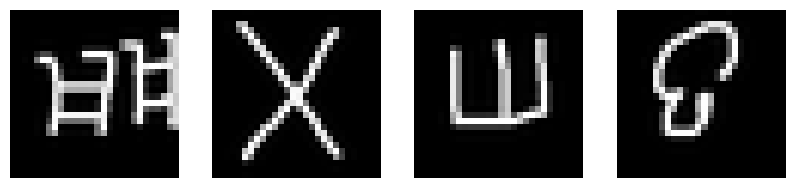

Evaluation data:


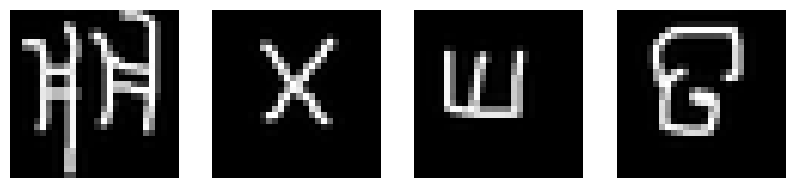

In [ ]:
visualize_task_omniglot(tasksets_omniglot.train.sample(), SHOTS, WAYS)

Adaptation data:


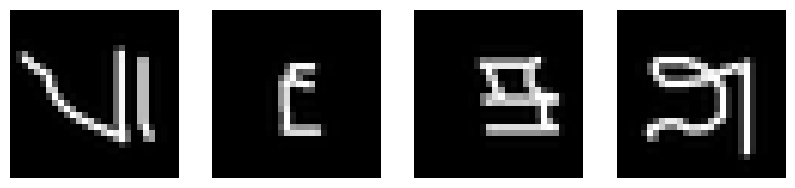

Evaluation data:


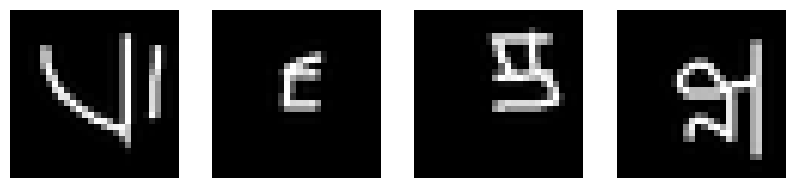

In [ ]:
visualize_task_omniglot(tasksets_omniglot.validation.sample(), SHOTS, WAYS)

Adaptation data:


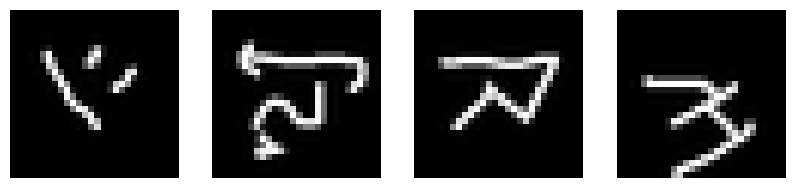

Evaluation data:


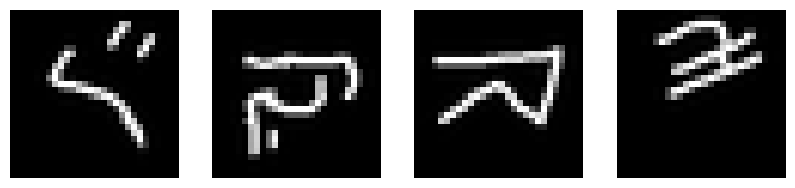

In [ ]:
visualize_task_omniglot(tasksets_omniglot.test.sample(), SHOTS, WAYS)

## Cargamos e inspeccionamos Mini-ImageNet

In [ ]:
# Si la descarga de archivos falla, los siguientes comandos se pueden correr para descargar los archivos manualmente
# !wget -O ~/data/mini-imagenet-cache-validation.pkl https://www.dropbox.com/s/ip1b7se3gij3r1b/mini-imagenet-cache-validation.pkl?dl=1
# !wget -O ~/data/mini-imagenet-cache-train.pkl https://www.dropbox.com/s/9g8c6w345s2ek03/mini-imagenet-cache-train.pkl?dl=1
# !wget -O ~/data/mini-imagenet-cache-test.pkl https://www.dropbox.com/s/ye9jeb5tyz0x01b/mini-imagenet-cache-test.pkl?dl=1

In [ ]:
tasksets_miniimagenet = l2l.vision.benchmarks.get_tasksets('mini-imagenet',
                                                           train_ways=WAYS,
                                                           train_samples=2*SHOTS,
                                                           test_ways=WAYS,
                                                           test_samples=2*SHOTS,
                                                           num_tasks=10000,
                                                           root='~/data',
)

Adaptation data:


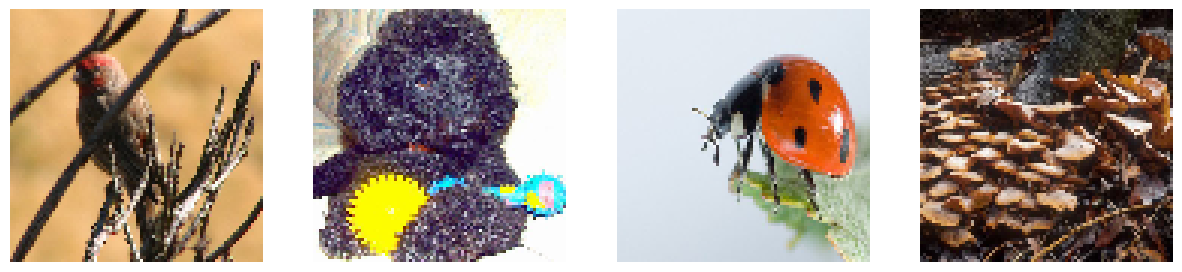

Evaluation data:


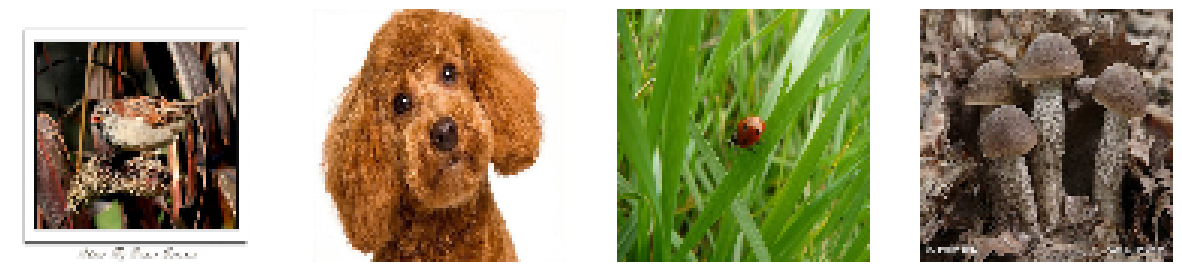

In [ ]:
visualize_task_miniimagenet(tasksets_miniimagenet.train.sample(), SHOTS, WAYS)

Adaptation data:


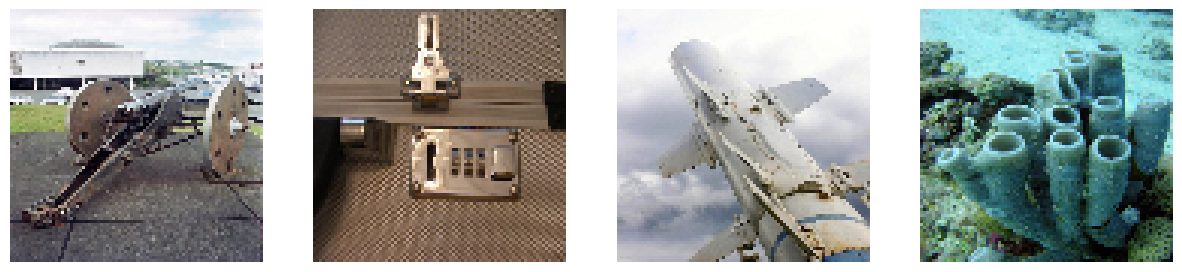

Evaluation data:


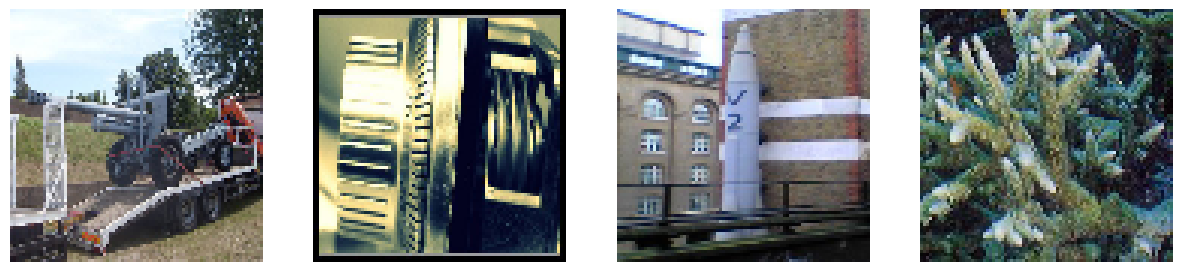

In [ ]:
visualize_task_miniimagenet(tasksets_miniimagenet.validation.sample(), SHOTS, WAYS)

Adaptation data:


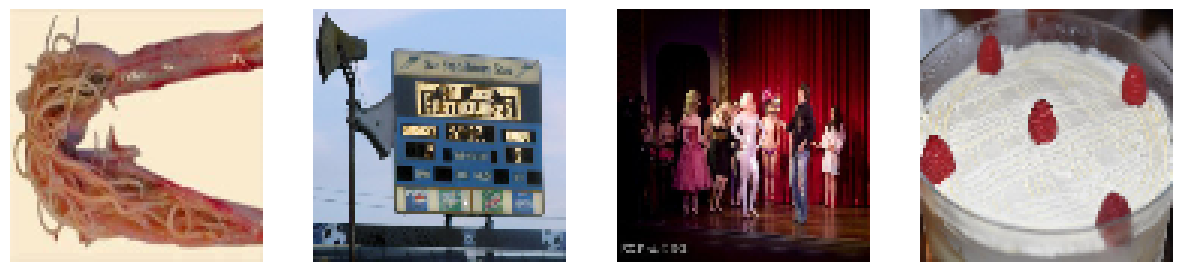

Evaluation data:


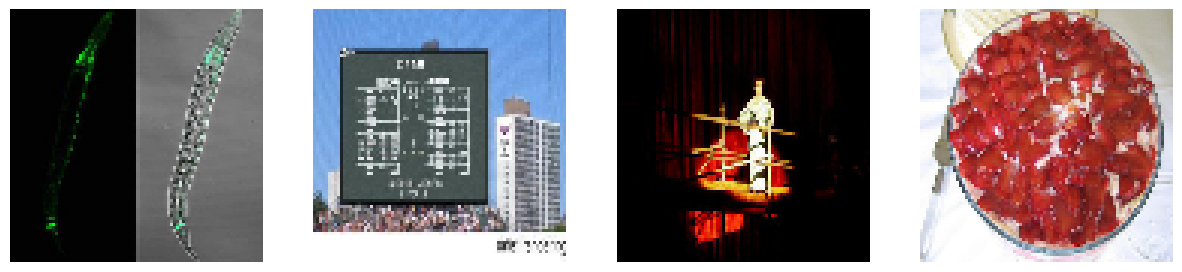

In [ ]:
visualize_task_miniimagenet(tasksets_miniimagenet.test.sample(), SHOTS, WAYS)

**IMPORTANTE**: Borramos tasksets y corremos garbage collection para ahorrar RAM (pueden ver el impacto a la derecha si abren el monitor de recursos)

In [ ]:
del tasksets_omniglot, tasksets_miniimagenet
gc.collect()

52570

# Algunas funciones de utilidad

In [ ]:
def plot_train_valid_curves(
    train_error: List[float],
    train_acc: List[float],
    valid_error: List[float],
    valid_acc: List[float],
    figsize: Tuple[int, int] = (10, 6),
) -> None:
    """
    Plot training and validation error/accuracy curves per epoch.

    Args:
        train_error: List of training error values per epoch.
        train_acc: List of training accuracy values per epoch.
        valid_error: List of validation error values per epoch.
        valid_acc: List of validation accuracy values per epoch.
        figsize: Tuple specifying the figure size (width, height).

    Returns:
        None. Displays the plots using matplotlib.
    """
    plt.figure(figsize=figsize)
    epochs = list(range(1, len(train_error) + 1))

    # Plot error curves
    plt.subplot(121)
    plt.title("Error per epoch")
    plt.plot(epochs, train_error, label="train_error")
    plt.plot(epochs, valid_error, label="valid_error")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend()

    # Plot accuracy curves
    plt.subplot(122)
    plt.title("Accuracy per epoch")
    plt.plot(epochs, train_acc, label="train_acc")
    plt.plot(epochs, valid_acc, label="valid_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()


def accuracy(predictions: torch.Tensor, targets: torch.Tensor) -> float:
    """
    Compute classification accuracy.

    Args:
        predictions: Model output logits of shape (batch_size, num_classes).
        targets: Ground-truth labels of shape (batch_size,).

    Returns:
        Accuracy as a float in the range [0, 1].
    """
    predicted_labels = predictions.argmax(dim=1).view(targets.shape)
    correct = (predicted_labels == targets).sum().float()
    return (correct / targets.size(0))

# Model-Agnostic Meta-Learning (MAML)

In [ ]:
def fast_adapt_MAML(
    batch: Tuple[torch.Tensor, torch.Tensor],
    learner: l2l.algorithms.MAML,
    loss: nn.Module,
    adaptation_steps: int,
    shots: int,
    ways: int,
    device: torch.device,
) -> Tuple[torch.Tensor, float]:
    """
    Perform fast adaptation for a single task in MAML.

    Args:
        batch: A tuple of (data, labels) sampled from the taskset.
        learner: A cloned model from the MAML meta-learner.
        loss: Loss function (e.g., CrossEntropyLoss).
        adaptation_steps: Number of inner-loop adaptation steps.
        shots: Number of examples per class for adaptation.
        ways: Number of classes per task.
        device: Torch device (CPU or CUDA).

    Returns:
        valid_error: Loss on the evaluation set.
        valid_accuracy: Accuracy on the evaluation set.
    """
    data, labels = batch
    data, labels = data.to(device), labels.to(device)

    # Separate data into adaptation/evaluation sets
    adaptation_indices = np.zeros(data.size(0), dtype=bool)
    adaptation_indices[np.arange(shots * ways) * 2] = True
    evaluation_indices = torch.from_numpy(~adaptation_indices)
    adaptation_indices = torch.from_numpy(adaptation_indices)

    adaptation_data, adaptation_labels = (
        data[adaptation_indices],
        labels[adaptation_indices],
    )
    evaluation_data, evaluation_labels = (
        data[evaluation_indices],
        labels[evaluation_indices],
    )

    # Adapt the model
    for step in range(adaptation_steps):
        train_error = loss(learner(adaptation_data), adaptation_labels)
        train_error /= len(adaptation_data)
        learner.adapt(train_error)

    # Evaluate the adapted model
    predictions = learner(evaluation_data)
    valid_error = loss(predictions, evaluation_labels)
    valid_error /= len(evaluation_data)
    valid_accuracy = accuracy(predictions, evaluation_labels)

    return valid_error, valid_accuracy


def run_MAML(
    dataset: str,
    model: nn.Module,
    device: torch.device,
    ways: int = 5,
    shots: int = 1,
    meta_lr: float = 0.003,
    fast_lr: float = 0.5,
    meta_batch_size: int = 32,
    adaptation_steps: int = 1,
    num_iterations: int = 100,
    cuda: bool = True,
    seed: int = 42,
    root: str = "~/data",
) -> None:
    """
    Run the MAML meta-learning algorithm on Omniglot or Mini-ImageNet.

    Args:
        dataset: Either 'omniglot' or 'mini-imagenet'.
        model: The base model to meta-learn.
        device: Torch device (CPU or CUDA).
        ways: Number of classes per task.
        shots: Number of examples per class for adaptation.
        meta_lr: Learning rate for the meta-optimizer.
        fast_lr: Learning rate for the inner-loop adaptation.
        meta_batch_size: Number of tasks per meta-batch.
        adaptation_steps: Number of inner-loop adaptation steps.
        num_iterations: Number of meta-training iterations.
        cuda: Whether to use CUDA.
        seed: Random seed for reproducibility.
        root: Path to dataset storage.

    Returns:
        None. Prints training/validation/test metrics and plots curves.
    """
    # Validate dataset choice
    if dataset not in ["omniglot", "mini-imagenet"]:
        raise ValueError("Dataset must be either 'omniglot' or 'mini-imagenet'.")

    # Set seeds
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if cuda:
        torch.cuda.manual_seed(seed)

    # Construct tasksets inside the function
    tasksets = l2l.vision.benchmarks.get_tasksets(
        dataset,
        train_ways=ways,
        train_samples=2 * shots,
        test_ways=ways,
        test_samples=2 * shots,
        num_tasks=10000,  # reduce if Colab runs out of memory
        root=root,
    )

    # MAML
    maml = l2l.algorithms.MAML(model, lr=fast_lr, first_order=True)

    # Optimizer
    opt = optim.Adam(maml.parameters(), meta_lr)

    # Classification loss
    loss = nn.CrossEntropyLoss(reduction="mean")

    # Error and accuracy lists for training and validation
    train_error, train_acc, valid_error, valid_acc = [], [], [], []

    # BEGIN MAIN LOOP
    for iteration in range(num_iterations):  # for each iteration

        # Reset gradient
        opt.zero_grad()

        # Reset auxiliary variables
        meta_train_error = 0.0
        meta_train_accuracy = 0.0
        meta_valid_error = 0.0
        meta_valid_accuracy = 0.0

        # BEGIN INNER LOOP
        # For each task in a batch of tasks of size meta_batch_size
        for task in range(meta_batch_size):

            # ----- Meta-training ------
            learner = maml.clone(first_order=True)
            batch = tasksets.train.sample()
            evaluation_error, evaluation_accuracy = fast_adapt_MAML(
                batch, learner, loss, adaptation_steps, shots, ways, device
            )
            evaluation_error.backward()
            meta_train_error += evaluation_error.item()
            meta_train_accuracy += evaluation_accuracy.item()

            # ----- Meta-validation ------
            learner = maml.clone(first_order=True)
            batch = tasksets.validation.sample()
            evaluation_error, evaluation_accuracy = fast_adapt_MAML(
                batch, learner, loss, adaptation_steps, shots, ways, device
            )
            meta_valid_error += evaluation_error.item()
            meta_valid_accuracy += evaluation_accuracy.item()
        # END OF INNER LOOP

        # Print some metrics for the current iteration
        clear_output(True)
        print("Iteration", iteration)
        print("Meta Train Error", meta_train_error / meta_batch_size)
        print("Meta Train Accuracy", meta_train_accuracy / meta_batch_size)
        print("Meta Valid Error", meta_valid_error / meta_batch_size)
        print("Meta Valid Accuracy", meta_valid_accuracy / meta_batch_size)

        train_error.append(meta_train_error / meta_batch_size)
        train_acc.append(meta_train_accuracy / meta_batch_size)
        valid_error.append(meta_valid_error / meta_batch_size)
        valid_acc.append(meta_valid_accuracy / meta_batch_size)

        # Average the accumulated gradients and optimize
        for p in maml.parameters():
            p.grad.data.mul_(1.0 / meta_batch_size)
        opt.step()

    # END MAIN LOOP

    # Plot training and validation curves
    plot_train_valid_curves(train_error, train_acc, valid_error, valid_acc)

    # ------ Meta-testing ------
    meta_test_error = 0.0
    meta_test_accuracy = 0.0
    for task in range(2000):
        learner = maml.clone(first_order=True)
        batch = tasksets.test.sample()
        evaluation_error, evaluation_accuracy = fast_adapt_MAML(
            batch, learner, loss, adaptation_steps, shots, ways, device
        )
        meta_test_error += evaluation_error.item()
        meta_test_accuracy += evaluation_accuracy.item()

    print("Meta Test Error", meta_test_error / 2000)
    print("Meta Test Accuracy", meta_test_accuracy / 2000)

    # Delete and garbage collect tasksets to save memory
    del tasksets
    gc.collect()

## MAML sobre Omniglot

Iteration 49
Meta Train Error 0.2113025198923424
Meta Train Accuracy 0.71875
Meta Valid Error 0.15371398942079395
Meta Valid Accuracy 0.8203125


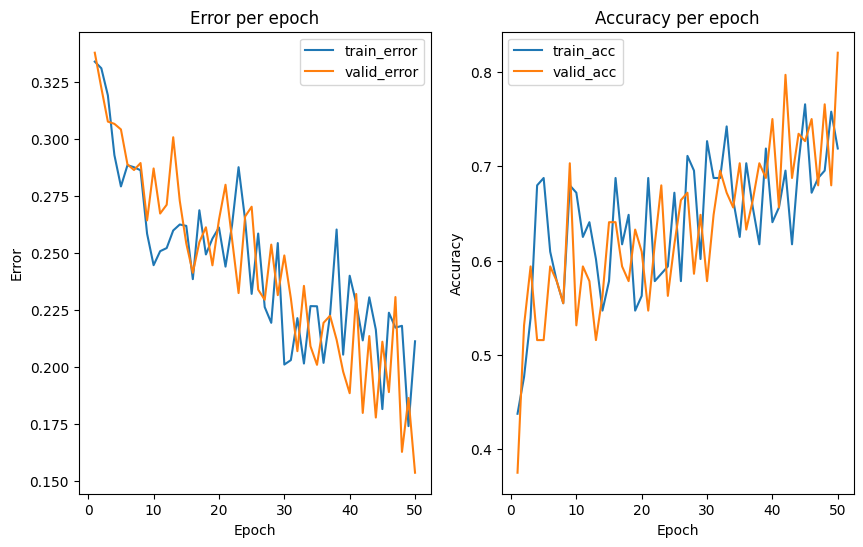

Meta Test Error 0.21396691013872624
Meta Test Accuracy 0.690875


In [ ]:
# Define model
model = l2l.vision.models.OmniglotFC(28 ** 2, WAYS) # 28 x 28 pixeles
model.to(device)

# Run MAML (tasksets are created inside run_MAML)
run_MAML(
    dataset="omniglot",
    model=model,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    num_iterations=50,
)

### Actividad 1

La función run_MAML() tiene algunos argumentos con los que se puede jugar, tales como el adaptation_steps, meta_lr, fast_lr, o incluso el modelo mismo. Modifique los argumentos que estime conveniente con el fin de mejorar los resultados obtenidos.

Si desea cambiar el modelo, puede definir su propio modelo o bien usar alguno de los modelos disponibles en l2l.vision.models (aquí la documentación: http://learn2learn.net/docs/learn2learn.vision/#learn2learnvisionmodels)

NOTA: en esta actividad NO se permite modificar WAYS y SHOTS (esto se hará en la actividad 2)

In [ ]:
# su código acá, puede agregar más celdas si lo desea

Comente sus resultados acá (**doble click para editar**)

### Actividad 2

Usando el mejor modelo e hiperparámetros que logró encontar en la Actividad 1:

* ¿cómo varían los resultados si ahora modifica el hiperparámetro WAYS?

* ¿cómo varían los resultados si modifica el hiperparámetro SHOTS?

NOTA: por experiencia previa, se recomienda no probar valores de WAYS y SHOTS muy grandes (no más allá de 8), ya que alumnos han reportado que colab puede caerse por consumo excesivo de memoria.

In [ ]:
# Su código acá, puede agregar más celdas si lo desea

# Abajo un ejemplo ilustrativo de cómo se pueden modificar WAYS y SHOTS.

WAYS = # algún valor
SHOTS = # algún valor

# IMPORTANTE: aquí debe ir el mejor modelo que usted haya encontrado
# en la actividad previa (no se especifica un modelo concreto).
model = # su mejor modelo de la actividad anterior
model.to(device)

# Ejecutar MAML (el dataset se crea dentro de run_MAML)
run_MAML(
    dataset="omniglot",   # o "mini-imagenet"
    model=model,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    num_iterations=60,    # o algún otro valor
    adaptation_steps=2,   # o algún otro valor
)

Comente sus resultados acá (**doble click para editar**)

## MAML sobre Mini-ImageNet

In [ ]:
WAYS = 4
SHOTS = 1

Iteration 59
Meta Train Error 0.37159252166748047
Meta Train Accuracy 0.265625
Meta Valid Error 0.3769146343693137
Meta Valid Accuracy 0.2578125


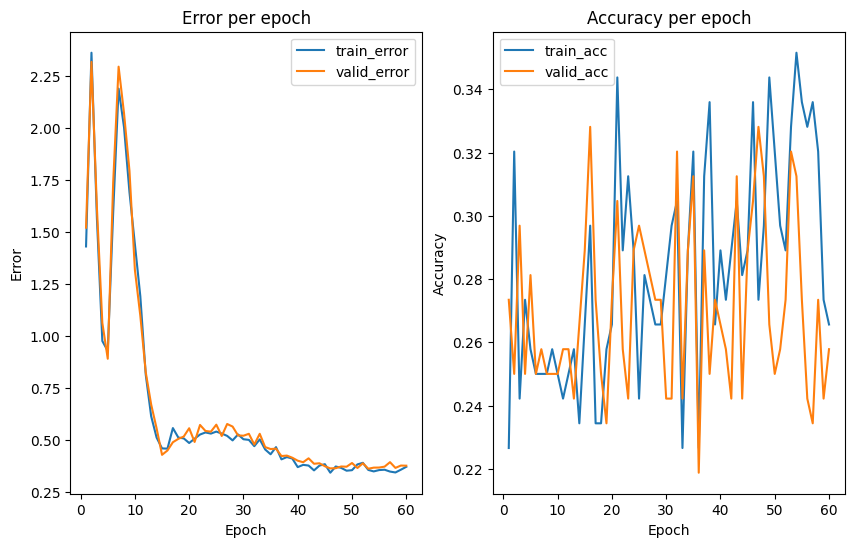

Meta Test Error 0.36927197893708946
Meta Test Accuracy 0.28675


In [ ]:
# Define model
model = l2l.vision.models.MiniImagenetCNN(WAYS)
model.to(device)

# Run MAML (tasksets are created inside run_MAML)
run_MAML(
    dataset="mini-imagenet",
    model=model,
    device=device,
    ways=WAYS,
    shots=SHOTS,
    num_iterations=60,
)

### Actividad 3

Vemos que 4-way, 1-shot classification en mini-imagenet es bastante más complicado que en omniglot, un resultado esperable ya que las imágenes en mini-imagenet son más complicadas. ¿Mejorarán los resultados si ...

1. ... aumentamos el hiperparámetro SHOTS?
2. ... disminuímos el hiperparámetro WAYS?
3. ... tratamos de probar mejores valores para los argumentos de la función run_MAML (learning rate, iteraciones, la CNN usada, etc.)?

NOTA: por experiencia previa, se recomienda no probar valores de WAYS y/o SHOTS muy grandes (no más allá de 8), ya que alumnos han reportado que colab puede caerse por consumo excesivo de memoria.

In [ ]:
# Su código acá, puede agregar más celdas si lo desea

Comente sus resultados acá (**doble click para editar**)